In [1]:
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.feature_selection import RFE
from sklearn.ensemble import VotingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from mlxtend.feature_selection import SequentialFeatureSelector
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,precision_score,recall_score,f1_score

In [2]:
# Read the data from local machine.
data = pd.read_csv("D:/Thesis/Model Apply 2017/CICIDS2017/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")
data.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [3]:
# Find the information about the dataset.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225745 entries, 0 to 225744
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             225745 non-null  int64  
 1    Flow Duration                225745 non-null  int64  
 2    Total Fwd Packets            225745 non-null  int64  
 3    Total Backward Packets       225745 non-null  int64  
 4   Total Length of Fwd Packets   225745 non-null  int64  
 5    Total Length of Bwd Packets  225745 non-null  int64  
 6    Fwd Packet Length Max        225745 non-null  int64  
 7    Fwd Packet Length Min        225745 non-null  int64  
 8    Fwd Packet Length Mean       225745 non-null  float64
 9    Fwd Packet Length Std        225745 non-null  float64
 10  Bwd Packet Length Max         225745 non-null  int64  
 11   Bwd Packet Length Min        225745 non-null  int64  
 12   Bwd Packet Length Mean       225745 non-nul

In [4]:
# Replace +ve and -ve infinity with NaN
# data.replace([np.inf, -np.inf], np.nan, inplace=True)

In [5]:
# Identify rows with NaN or infinity values
rows_with_nan = data.isnull().any(axis=1)
rows_with_inf = data.isin([np.inf, -np.inf]).any(axis=1)

# Combine both conditions to identify rows with NaN or infinity values
rows_to_delete = rows_with_nan | rows_with_inf

# Keep track of the deleted rows
deleted_rows = data[rows_to_delete]

# Remove rows with NaN or infinity values
data_cleaned = data[~rows_to_delete]

print("\nDeleted Rows:")
pd.set_option("display.max_columns", len(deleted_rows.columns))

# Display the entire DataFrame
print(deleted_rows)

# Reset the display option to its default (if needed)
pd.reset_option("display.max_columns")


Deleted Rows:
         Destination Port   Flow Duration   Total Fwd Packets  \
65                  55043               0                   2   
1767                60018               0                   2   
1890                   80               0                   1   
3375                  443               0                   1   
6796                36812               0                   2   
8057                35382               0                   1   
8405                55421               0                   2   
13313                9242               0                   2   
13716                 389               0                   2   
14739               53581               0                   1   
15047                  80               0                   2   
18253               57919               0                   2   
33330               59646               0                   2   
55551                  80               0                   1   
61529     

In [6]:
data = data_cleaned
data.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [7]:
# See the mean,standard deviation,min, max of each column.
data.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,225711.000000,2.257110e+05,225711.000000,225711.000000,225711.000000,2.257110e+05,225711.000000,225711.000000,225711.000000,225711.000000,...,225711.00000,225711.000000,2.257110e+05,2.257110e+05,2.257110e+05,2.257110e+05,2.257110e+05,2.257110e+05,2.257110e+05,2.257110e+05
mean,8876.556769,1.624410e+07,4.875389,4.573424,939.603147,5.961369e+03,538.615499,27.885810,164.850580,214.939117,...,3.31193,21.482338,1.848539e+05,1.293631e+04,2.081162e+05,1.776468e+05,1.032370e+07,3.612487e+06,1.288007e+07,7.756523e+06
std,19752.018851,3.152612e+07,15.423986,21.756929,3249.628245,3.922122e+04,1864.258043,163.336194,504.927243,797.466898,...,12.27089,4.166228,7.979819e+05,2.102894e+05,9.002992e+05,7.843163e+05,2.185431e+07,1.275778e+07,2.692283e+07,1.983236e+07
min,0.000000,-1.000000e+00,1.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,80.000000,7.123800e+04,2.000000,1.000000,26.000000,0.000000e+00,6.000000,0.000000,6.000000,0.000000,...,1.00000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,80.000000,1.453164e+06,3.000000,4.000000,30.000000,1.640000e+02,20.000000,0.000000,8.666667,5.301991,...,2.00000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,80.000000,8.806652e+06,5.000000,5.000000,64.000000,1.160100e+04,34.000000,6.000000,32.000000,10.263203,...,4.00000,20.000000,1.879000e+03,0.000000e+00,1.879000e+03,1.863000e+03,8.241416e+06,0.000000e+00,8.254452e+06,7.423865e+06
max,65532.000000,1.199999e+08,1932.000000,2942.000000,183012.000000,5.172346e+06,11680.000000,1472.000000,3867.000000,6692.644993,...,1931.00000,52.000000,1.000000e+08,3.950000e+07,1.000000e+08,1.000000e+08,1.200000e+08,6.530000e+07,1.200000e+08,1.200000e+08


In [8]:
# Check total number of null cloumn in this dataset.
columns = data.columns
for i in columns:
    if data[i].isnull().sum() > 0:
        print(i)

In [9]:
# Drop missing values
data.dropna(inplace=True)

In [10]:
# To see how many record fall in each classes.
data[' Label'].value_counts()

 Label
DDoS      128025
BENIGN     97686
Name: count, dtype: int64

### Plot the orginal dataset distribution.

In [11]:
from plotly.offline import init_notebook_mode, iplot, plot
import plotly as py
import plotly.express as px
init_notebook_mode(connected=True)
import plotly.graph_objs as go

fig = go.Figure(data=[
    go.Bar(name='DDoS', 
           y=data[" Label"].value_counts().values[0:1],
           x=['DDoS'],
           text = data[" Label"].value_counts()[0:1],
           orientation='v',
           textposition='outside',),
    go.Bar(name='BENIGN', 
           y=data[" Label"].value_counts().values[1:2],
           x=['BENIGN'],
           text = data[" Label"].value_counts()[1:2],
           orientation='v',
           textposition='outside',)
])
# Change the bar mode
fig.update_layout(
                  width=800,
                  height=600,
                  title=f'Class Distribution',
                  yaxis_title='Number of attacks',
                  xaxis_title='Attack Name',)
iplot(fig)

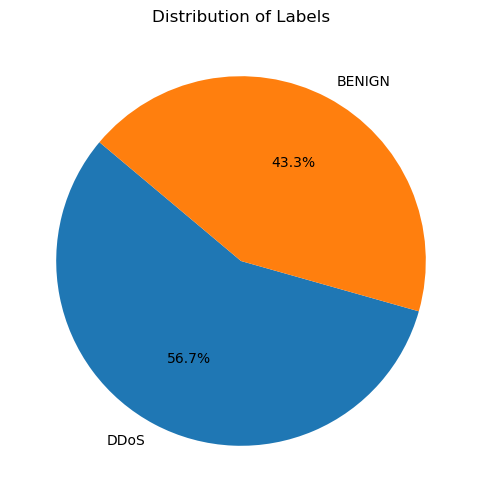

In [12]:
import matplotlib.pyplot as plt
# Assuming data is a pandas DataFrame
data1 = {'Label': ['DDoS', 'BENIGN'],
        'Count': [128025, 97686]}

# Plotting the pie chart
plt.figure(figsize=(6, 6))
plt.pie(data1['Count'], labels=data1['Label'], autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Labels')
plt.show()

In [13]:
# Divided the data into the train independent variable and target variable.
x = data.iloc[:,:-1]
y = data[' Label']

In [14]:
# Perform the train test split for feed the data into model.
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,stratify=y, random_state=42)

# Data Transformation

In [93]:
# Apply the standard Scaler.
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.fit_transform(x_test)

In [94]:
x = scaler.fit_transform(x)

In [95]:
# Apply the label encoding to the target cloumn.
le = LabelEncoder()
y_train = le.fit_transform(np.ravel(y_train))
y_test = le.fit_transform(np.ravel(y_test))

In [96]:
y = le.fit_transform(y)

# Different Model Apply 

### Logistic Regression

In [21]:
RawLogisticRegression = LogisticRegression()

In [97]:
RawLogisticRegressionResult = cross_val_score(RawLogisticRegression,x,y,cv=5)

In [99]:
print(RawLogisticRegressionResult.mean())

0.9983518757826655


In [22]:
RawLogisticRegression.fit(x_train,y_train)

LogisticRegression()

In [23]:
yPredLogisticRegression = RawLogisticRegression.predict(x_test)

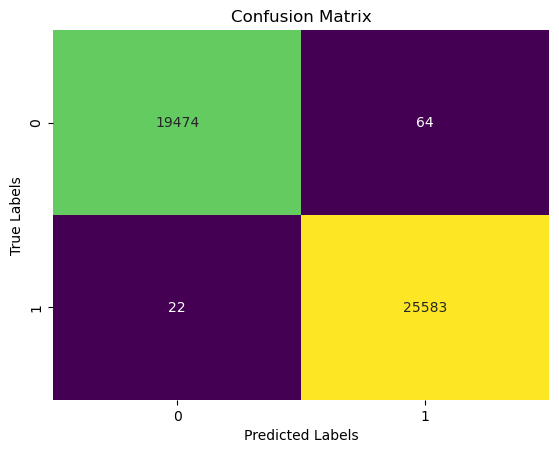

In [24]:
confMat = confusion_matrix(y_test,yPredLogisticRegression)
sns.heatmap(confMat, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [25]:
# Print the classification report.
print(format(classification_report(y_test,yPredLogisticRegression)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19538
           1       1.00      1.00      1.00     25605

    accuracy                           1.00     45143
   macro avg       1.00      1.00      1.00     45143
weighted avg       1.00      1.00      1.00     45143



In [26]:
# Print accuracy, F1-score, Recall, Precision.
print("f1 Score {}".format(f1_score(y_test,yPredLogisticRegression)))
print("Recall Score {}".format(recall_score(y_test,yPredLogisticRegression)))
print("Accuracy Score {}".format(accuracy_score(y_test,yPredLogisticRegression)))
print("Precision Score {}".format(precision_score(y_test,yPredLogisticRegression)))

f1 Score 0.9983220167017872
Recall Score 0.9991407928139036
Accuracy Score 0.998094942737523
Precision Score 0.9975045814325262


### Gradient Boosting

In [27]:
RawGradinetBoosting = GradientBoostingClassifier()

In [100]:
RawGradinetBoostingResult = cross_val_score(RawGradinetBoosting,x,y,cv=5,n_jobs=-1,verbose=2)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:  9.1min remaining: 13.7min
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  9.4min remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  9.4min finished


In [101]:
print(RawGradinetBoostingResult.mean())

0.9992734053975342


In [28]:
RawGradinetBoosting.fit(x_train,y_train)

GradientBoostingClassifier()

In [29]:
yPredGradientBoosting = RawGradinetBoosting.predict(x_test)

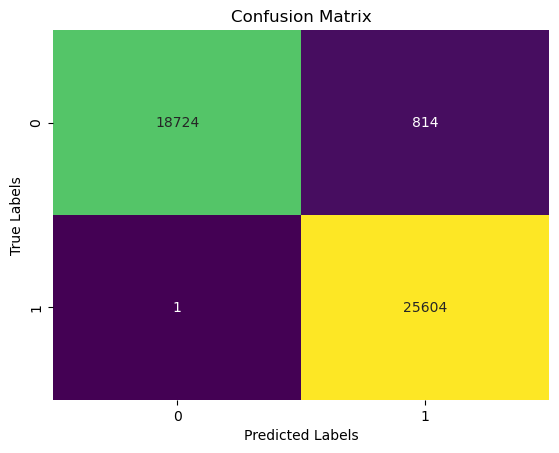

In [30]:
confMat = confusion_matrix(y_test,yPredGradientBoosting)
sns.heatmap(confMat, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [31]:
print(format(classification_report(y_test,yPredGradientBoosting)))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98     19538
           1       0.97      1.00      0.98     25605

    accuracy                           0.98     45143
   macro avg       0.98      0.98      0.98     45143
weighted avg       0.98      0.98      0.98     45143



In [32]:
print("f1 Score {}".format(f1_score(y_test,yPredGradientBoosting)))
print("Recall Score {}".format(recall_score(y_test,yPredGradientBoosting)))
print("Accuracy Score {}".format(accuracy_score(y_test,yPredGradientBoosting)))
print("Precision Score {}".format(precision_score(y_test,yPredGradientBoosting)))

f1 Score 0.9843338523345443
Recall Score 0.9999609451279047
Accuracy Score 0.9819462596637353
Precision Score 0.969187675070028


### AdaBoosting

In [72]:
RawAdaBoosting = AdaBoostClassifier()

In [102]:
RawAdaBoostingResult = cross_val_score(RawAdaBoosting,x,y,cv=5,verbose=2,n_jobs=-1)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:  1.8min remaining:  2.7min
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  1.8min remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  1.8min finished


In [103]:
print(RawAdaBoostingResult.mean())

0.999707592328895


In [73]:
RawAdaBoosting.fit(x_train,y_train)

C:\Users\rafi\AppData\Roaming\Python\Python311\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning:

The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.



AdaBoostClassifier()

In [74]:
yPredAdaBoosting = RawAdaBoosting.predict(x_test)

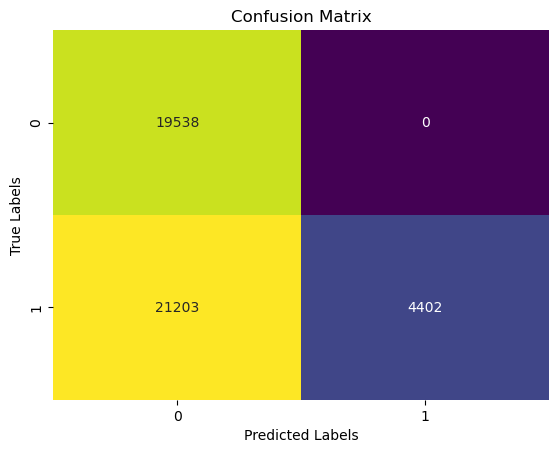

In [75]:
confMat = confusion_matrix(y_test,yPredAdaBoosting)
sns.heatmap(confMat, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [76]:
print(format(classification_report(y_test,yPredAdaBoosting)))

              precision    recall  f1-score   support

           0       0.48      1.00      0.65     19538
           1       1.00      0.17      0.29     25605

    accuracy                           0.53     45143
   macro avg       0.74      0.59      0.47     45143
weighted avg       0.77      0.53      0.45     45143



In [77]:
print("f1 Score {}".format(f1_score(y_test,yPredAdaBoosting)))
print("Recall Score {}".format(recall_score(y_test,yPredAdaBoosting)))
print("Accuracy Score {}".format(accuracy_score(y_test,yPredAdaBoosting)))
print("Precision Score {}".format(precision_score(y_test,yPredAdaBoosting)))

f1 Score 0.2933982070850135
Recall Score 0.1719195469634837
Accuracy Score 0.5303147774848814
Precision Score 1.0


### CatBoosting

In [39]:
RawCatBoosting = CatBoostClassifier()

In [104]:
RawCatBoostingResult = cross_val_score(RawCatBoosting,x,y,cv=5,verbose=3,n_jobs=-1)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:  4.8min remaining:  7.2min
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  4.9min finished


In [105]:
print(RawCatBoostingResult.mean())

0.9993974575025962


In [40]:
RawCatBoosting.fit(x_train,y_train)

Learning rate set to 0.094737
0:	learn: 0.4112620	total: 188ms	remaining: 3m 7s
1:	learn: 0.2217588	total: 237ms	remaining: 1m 58s
2:	learn: 0.1339485	total: 276ms	remaining: 1m 31s
3:	learn: 0.0748928	total: 316ms	remaining: 1m 18s
4:	learn: 0.0432668	total: 356ms	remaining: 1m 10s
5:	learn: 0.0272325	total: 396ms	remaining: 1m 5s
6:	learn: 0.0178029	total: 438ms	remaining: 1m 2s
7:	learn: 0.0129908	total: 490ms	remaining: 1m
8:	learn: 0.0103096	total: 531ms	remaining: 58.5s
9:	learn: 0.0089279	total: 569ms	remaining: 56.3s
10:	learn: 0.0074194	total: 616ms	remaining: 55.4s
11:	learn: 0.0063276	total: 682ms	remaining: 56.1s
12:	learn: 0.0056792	total: 733ms	remaining: 55.7s
13:	learn: 0.0046235	total: 787ms	remaining: 55.4s
14:	learn: 0.0040773	total: 832ms	remaining: 54.7s
15:	learn: 0.0038703	total: 870ms	remaining: 53.5s
16:	learn: 0.0036194	total: 904ms	remaining: 52.3s
17:	learn: 0.0032586	total: 950ms	remaining: 51.8s
18:	learn: 0.0030535	total: 993ms	remaining: 51.3s
19:	learn:

163:	learn: 0.0004818	total: 6.6s	remaining: 33.6s
164:	learn: 0.0004818	total: 6.64s	remaining: 33.6s
165:	learn: 0.0004818	total: 6.68s	remaining: 33.6s
166:	learn: 0.0004818	total: 6.71s	remaining: 33.5s
167:	learn: 0.0004818	total: 6.75s	remaining: 33.4s
168:	learn: 0.0004818	total: 6.79s	remaining: 33.4s
169:	learn: 0.0004818	total: 6.83s	remaining: 33.3s
170:	learn: 0.0004818	total: 6.87s	remaining: 33.3s
171:	learn: 0.0004818	total: 6.91s	remaining: 33.3s
172:	learn: 0.0004818	total: 6.95s	remaining: 33.2s
173:	learn: 0.0004818	total: 6.98s	remaining: 33.1s
174:	learn: 0.0004819	total: 7.02s	remaining: 33.1s
175:	learn: 0.0004819	total: 7.06s	remaining: 33.1s
176:	learn: 0.0004819	total: 7.1s	remaining: 33s
177:	learn: 0.0004819	total: 7.13s	remaining: 32.9s
178:	learn: 0.0004819	total: 7.17s	remaining: 32.9s
179:	learn: 0.0004819	total: 7.21s	remaining: 32.8s
180:	learn: 0.0004819	total: 7.25s	remaining: 32.8s
181:	learn: 0.0004819	total: 7.29s	remaining: 32.8s
182:	learn: 0.00

322:	learn: 0.0004819	total: 12.9s	remaining: 27s
323:	learn: 0.0004819	total: 12.9s	remaining: 26.9s
324:	learn: 0.0004819	total: 12.9s	remaining: 26.9s
325:	learn: 0.0004819	total: 13s	remaining: 26.8s
326:	learn: 0.0004819	total: 13s	remaining: 26.8s
327:	learn: 0.0004819	total: 13.1s	remaining: 26.8s
328:	learn: 0.0004819	total: 13.1s	remaining: 26.7s
329:	learn: 0.0004819	total: 13.1s	remaining: 26.7s
330:	learn: 0.0004819	total: 13.2s	remaining: 26.7s
331:	learn: 0.0004819	total: 13.2s	remaining: 26.6s
332:	learn: 0.0004819	total: 13.3s	remaining: 26.6s
333:	learn: 0.0004819	total: 13.3s	remaining: 26.5s
334:	learn: 0.0004819	total: 13.3s	remaining: 26.5s
335:	learn: 0.0004819	total: 13.4s	remaining: 26.4s
336:	learn: 0.0004819	total: 13.4s	remaining: 26.4s
337:	learn: 0.0004819	total: 13.5s	remaining: 26.4s
338:	learn: 0.0004819	total: 13.5s	remaining: 26.3s
339:	learn: 0.0004819	total: 13.5s	remaining: 26.3s
340:	learn: 0.0004819	total: 13.6s	remaining: 26.2s
341:	learn: 0.0004

483:	learn: 0.0004819	total: 19.9s	remaining: 21.2s
484:	learn: 0.0004819	total: 20s	remaining: 21.2s
485:	learn: 0.0004819	total: 20s	remaining: 21.2s
486:	learn: 0.0004819	total: 20.1s	remaining: 21.1s
487:	learn: 0.0004819	total: 20.1s	remaining: 21.1s
488:	learn: 0.0004819	total: 20.2s	remaining: 21.1s
489:	learn: 0.0004819	total: 20.2s	remaining: 21s
490:	learn: 0.0004819	total: 20.2s	remaining: 21s
491:	learn: 0.0004819	total: 20.3s	remaining: 21s
492:	learn: 0.0004819	total: 20.3s	remaining: 20.9s
493:	learn: 0.0004819	total: 20.4s	remaining: 20.9s
494:	learn: 0.0004819	total: 20.4s	remaining: 20.8s
495:	learn: 0.0004819	total: 20.5s	remaining: 20.8s
496:	learn: 0.0004819	total: 20.5s	remaining: 20.8s
497:	learn: 0.0004819	total: 20.6s	remaining: 20.7s
498:	learn: 0.0004819	total: 20.6s	remaining: 20.7s
499:	learn: 0.0004819	total: 20.7s	remaining: 20.7s
500:	learn: 0.0004819	total: 20.7s	remaining: 20.6s
501:	learn: 0.0004819	total: 20.7s	remaining: 20.6s
502:	learn: 0.0004819	

643:	learn: 0.0004819	total: 27.3s	remaining: 15.1s
644:	learn: 0.0004819	total: 27.3s	remaining: 15s
645:	learn: 0.0004819	total: 27.4s	remaining: 15s
646:	learn: 0.0004819	total: 27.4s	remaining: 15s
647:	learn: 0.0004819	total: 27.5s	remaining: 14.9s
648:	learn: 0.0004819	total: 27.5s	remaining: 14.9s
649:	learn: 0.0004819	total: 27.6s	remaining: 14.8s
650:	learn: 0.0004819	total: 27.6s	remaining: 14.8s
651:	learn: 0.0004819	total: 27.7s	remaining: 14.8s
652:	learn: 0.0004819	total: 27.7s	remaining: 14.7s
653:	learn: 0.0004819	total: 27.8s	remaining: 14.7s
654:	learn: 0.0004819	total: 27.8s	remaining: 14.6s
655:	learn: 0.0004819	total: 27.8s	remaining: 14.6s
656:	learn: 0.0004819	total: 27.9s	remaining: 14.6s
657:	learn: 0.0004819	total: 27.9s	remaining: 14.5s
658:	learn: 0.0004819	total: 28s	remaining: 14.5s
659:	learn: 0.0004819	total: 28s	remaining: 14.4s
660:	learn: 0.0004819	total: 28.1s	remaining: 14.4s
661:	learn: 0.0004819	total: 28.1s	remaining: 14.4s
662:	learn: 0.0004819	

802:	learn: 0.0004819	total: 37.8s	remaining: 9.26s
803:	learn: 0.0004819	total: 37.8s	remaining: 9.22s
804:	learn: 0.0004819	total: 37.9s	remaining: 9.17s
805:	learn: 0.0004819	total: 37.9s	remaining: 9.12s
806:	learn: 0.0004819	total: 37.9s	remaining: 9.07s
807:	learn: 0.0004819	total: 38s	remaining: 9.03s
808:	learn: 0.0004819	total: 38s	remaining: 8.98s
809:	learn: 0.0004819	total: 38.1s	remaining: 8.93s
810:	learn: 0.0004819	total: 38.1s	remaining: 8.88s
811:	learn: 0.0004819	total: 38.2s	remaining: 8.84s
812:	learn: 0.0004819	total: 38.2s	remaining: 8.79s
813:	learn: 0.0004819	total: 38.3s	remaining: 8.74s
814:	learn: 0.0004819	total: 38.3s	remaining: 8.7s
815:	learn: 0.0004819	total: 38.4s	remaining: 8.65s
816:	learn: 0.0004819	total: 38.4s	remaining: 8.6s
817:	learn: 0.0004819	total: 38.5s	remaining: 8.55s
818:	learn: 0.0004819	total: 38.5s	remaining: 8.51s
819:	learn: 0.0004819	total: 38.5s	remaining: 8.46s
820:	learn: 0.0004819	total: 38.6s	remaining: 8.41s
821:	learn: 0.0004

961:	learn: 0.0004819	total: 45.1s	remaining: 1.78s
962:	learn: 0.0004819	total: 45.1s	remaining: 1.73s
963:	learn: 0.0004819	total: 45.2s	remaining: 1.69s
964:	learn: 0.0004819	total: 45.2s	remaining: 1.64s
965:	learn: 0.0004819	total: 45.3s	remaining: 1.59s
966:	learn: 0.0004819	total: 45.3s	remaining: 1.55s
967:	learn: 0.0004819	total: 45.4s	remaining: 1.5s
968:	learn: 0.0004819	total: 45.4s	remaining: 1.45s
969:	learn: 0.0004819	total: 45.5s	remaining: 1.41s
970:	learn: 0.0004819	total: 45.5s	remaining: 1.36s
971:	learn: 0.0004819	total: 45.5s	remaining: 1.31s
972:	learn: 0.0004819	total: 45.6s	remaining: 1.26s
973:	learn: 0.0004819	total: 45.6s	remaining: 1.22s
974:	learn: 0.0004819	total: 45.7s	remaining: 1.17s
975:	learn: 0.0004819	total: 45.7s	remaining: 1.12s
976:	learn: 0.0004819	total: 45.8s	remaining: 1.08s
977:	learn: 0.0004819	total: 45.8s	remaining: 1.03s
978:	learn: 0.0004819	total: 45.9s	remaining: 984ms
979:	learn: 0.0004819	total: 45.9s	remaining: 937ms
980:	learn: 0

In [41]:
yPredCatBoosting = RawCatBoosting.predict(x_test)

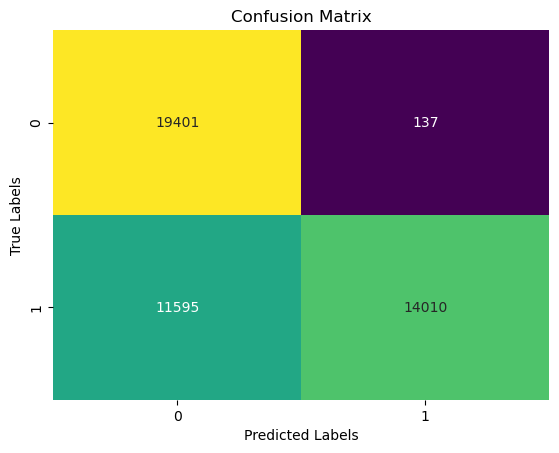

In [42]:
confMat = confusion_matrix(y_test,yPredCatBoosting)
sns.heatmap(confMat, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [43]:
print(format(classification_report(y_test,yPredCatBoosting)))

              precision    recall  f1-score   support

           0       0.63      0.99      0.77     19538
           1       0.99      0.55      0.70     25605

    accuracy                           0.74     45143
   macro avg       0.81      0.77      0.74     45143
weighted avg       0.83      0.74      0.73     45143



In [44]:
print("f1 Score {}".format(f1_score(y_test,yPredCatBoosting)))
print("Recall Score {}".format(recall_score(y_test,yPredCatBoosting)))
print("Accuracy Score {}".format(accuracy_score(y_test,yPredCatBoosting)))
print("Precision Score {}".format(precision_score(y_test,yPredCatBoosting)))

f1 Score 0.7048701952103039
Recall Score 0.5471587580550674
Accuracy Score 0.7401147464723213
Precision Score 0.9903159680497632


### LightGBM

In [106]:
RawLightGBM = LGBMClassifier()

In [107]:
RawLightGBMResult = cross_val_score(RawLightGBM,x,y,cv=5,verbose=1,n_jobs=-1)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:   14.0s remaining:   21.1s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   14.4s finished


In [108]:
print(RawLightGBMResult.mean())

0.999756325174174


In [46]:
RawLightGBM.fit(x_train,y_train)

[LightGBM] [Info] Number of positive: 102420, number of negative: 78148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.056793 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14235
[LightGBM] [Info] Number of data points in the train set: 180568, number of used features: 68
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.567210 -> initscore=0.270478
[LightGBM] [Info] Start training from score 0.270478


LGBMClassifier()

In [47]:
yPredLightGBM = RawLightGBM.predict(x_test)

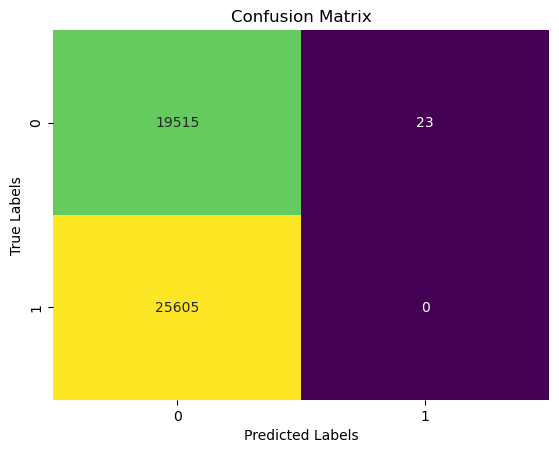

In [48]:
confMat = confusion_matrix(y_test,yPredLightGBM)
sns.heatmap(confMat, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [49]:
print(format(classification_report(y_test,yPredLightGBM)))

              precision    recall  f1-score   support

           0       0.43      1.00      0.60     19538
           1       0.00      0.00      0.00     25605

    accuracy                           0.43     45143
   macro avg       0.22      0.50      0.30     45143
weighted avg       0.19      0.43      0.26     45143



In [50]:
print("f1 Score {}".format(f1_score(y_test,yPredLightGBM)))
print("Recall Score {}".format(recall_score(y_test,yPredLightGBM)))
print("Accuracy Score {}".format(accuracy_score(y_test,yPredLightGBM)))
print("Precision Score {}".format(precision_score(y_test,yPredLightGBM)))

f1 Score 0.0
Recall Score 0.0
Accuracy Score 0.4322929357818488
Precision Score 0.0


### XGBoosting

In [109]:
RawXGBoost = XGBClassifier()

In [110]:
RawXGBoostResult = cross_val_score(RawXGBoost,x,y,cv=5,verbose=1,n_jobs=-1)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    7.2s remaining:   10.8s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   13.3s finished


In [111]:
print(RawXGBoostResult.mean())

0.9997917689832734


In [52]:
RawXGBoost.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [53]:
yPredXGBoost = RawXGBoost.predict(x_test)

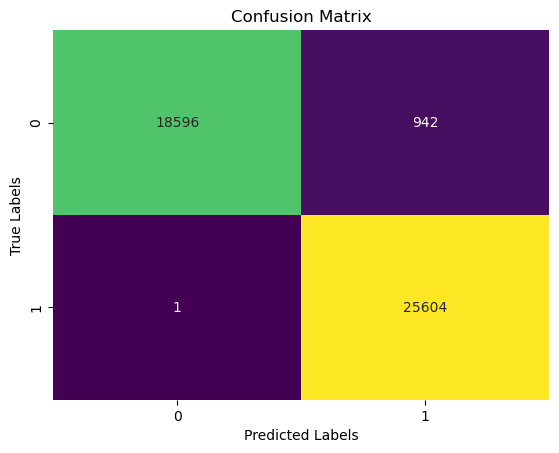

In [54]:
confMat = confusion_matrix(y_test,yPredXGBoost)
sns.heatmap(confMat, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [55]:
print(format(classification_report(y_test,yPredXGBoost)))

              precision    recall  f1-score   support

           0       1.00      0.95      0.98     19538
           1       0.96      1.00      0.98     25605

    accuracy                           0.98     45143
   macro avg       0.98      0.98      0.98     45143
weighted avg       0.98      0.98      0.98     45143



In [56]:
print("f1 Score {}".format(f1_score(y_test,yPredXGBoost)))
print("Recall Score {}".format(recall_score(y_test,yPredXGBoost)))
print("Accuracy Score {}".format(accuracy_score(y_test,yPredXGBoost)))
print("Precision Score {}".format(precision_score(y_test,yPredXGBoost)))

f1 Score 0.9819178922743571
Recall Score 0.9999609451279047
Accuracy Score 0.9791108255986531
Precision Score 0.9645144277857304


### Decision Tree

In [115]:
RawDecisionTree = DecisionTreeClassifier()

In [116]:
RawDecisionTreeResult = cross_val_score(RawDecisionTree,x,y,cv=5,verbose=1,n_jobs=-1)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    5.3s remaining:    8.0s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    9.8s finished


In [117]:
print(RawDecisionTreeResult.mean())

0.9992822665215589


In [58]:
RawDecisionTree.fit(x_train,y_train)

DecisionTreeClassifier()

In [59]:
yPredDecisionTree = RawDecisionTree.predict(x_test)

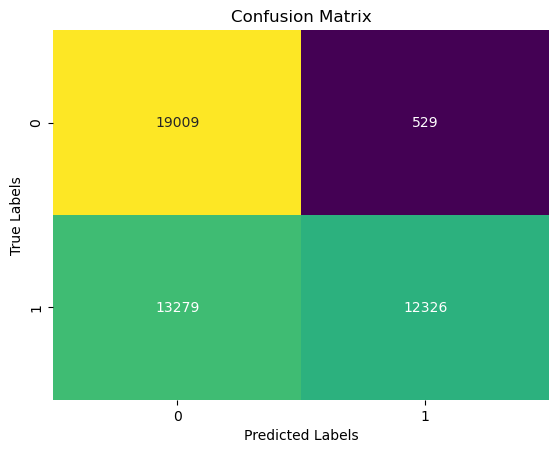

In [60]:
confMat = confusion_matrix(y_test,yPredDecisionTree)
sns.heatmap(confMat, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [61]:
print(format(classification_report(y_test,yPredDecisionTree)))

              precision    recall  f1-score   support

           0       0.59      0.97      0.73     19538
           1       0.96      0.48      0.64     25605

    accuracy                           0.69     45143
   macro avg       0.77      0.73      0.69     45143
weighted avg       0.80      0.69      0.68     45143



In [62]:
print("f1 Score {}".format(f1_score(y_test,yPredDecisionTree)))
print("Recall Score {}".format(recall_score(y_test,yPredDecisionTree)))
print("Accuracy Score {}".format(accuracy_score(y_test,yPredDecisionTree)))
print("Precision Score {}".format(precision_score(y_test,yPredDecisionTree)))

f1 Score 0.6409776391055643
Recall Score 0.4813903534465925
Accuracy Score 0.6941275502292714
Precision Score 0.9588486970050564


### Random Forest

In [118]:
RawRandomForest = RandomForestClassifier()

In [119]:
RawRandomForestResult = cross_val_score(RawRandomForest,x,y,cv=5,verbose=1,n_jobs=-1)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:  1.8min remaining:  2.7min
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  1.8min finished


In [120]:
print(RawRandomForestResult.mean())

0.9994284706515402


## Voting Classifier

### Hard Voting

In [121]:
estimators = [("lr",RawLogisticRegression),("Gb",RawGradinetBoosting),("Ab",RawAdaBoosting),("Xb",RawXGBoost),("Rf",RawRandomForest)]

In [122]:
RawVotingClassifier = VotingClassifier(estimators=estimators,voting='hard')
result = cross_val_score(RawVotingClassifier,x,y,cv=10,scoring='accuracy')
# print(np.round(np.mean(result),2))

C:\Users\rafi\AppData\Roaming\Python\Python311\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning:

The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.

C:\Users\rafi\AppData\Roaming\Python\Python311\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning:

The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.

C:\Users\rafi\AppData\Roaming\Python\Python311\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning:

The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.

C:\Users\rafi\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) o

In [123]:
print(np.mean(result)*100)

99.97784775916472


### Soft Voting

In [124]:
RawVotingClassifier = VotingClassifier(estimators=estimators,voting='soft')
result = cross_val_score(RawVotingClassifier,x,y,cv=5,scoring='accuracy')

C:\Users\rafi\AppData\Roaming\Python\Python311\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning:

The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.

C:\Users\rafi\AppData\Roaming\Python\Python311\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning:

The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.

C:\Users\rafi\AppData\Roaming\Python\Python311\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning:

The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.

C:\Users\rafi\AppData\Roaming\Python\Python311\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning:

The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.



In [125]:
print(np.mean(result)*100)

99.97873381268325


### Stacking

In [126]:
StackEstimetors = [("Lr",RawLogisticRegression),("Dt",RawDecisionTree),("Ab",RawAdaBoosting),("Gb",RawGradinetBoosting),("Rf",RawRandomForest)]

In [127]:
RawStacking = StackingClassifier(estimators=StackEstimetors,final_estimator=RawXGBoost,cv=5)

In [128]:
Result2 = cross_val_score(RawStacking,x,y,cv=5,verbose=1,n_jobs=-1)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed: 51.1min remaining: 76.6min
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed: 51.6min finished


In [114]:
yPredStacking = RawStacking.predict(x_test)

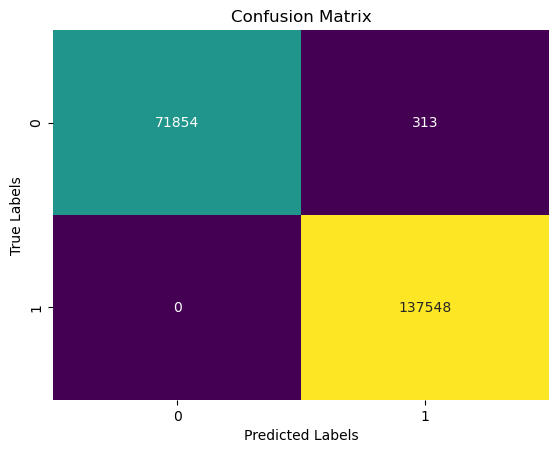

In [116]:
confMat = confusion_matrix(y_test,yPredStacking)
sns.heatmap(confMat, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [117]:
print(format(classification_report(y_test,yPredStacking)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     72167
           1       1.00      1.00      1.00    137548

    accuracy                           1.00    209715
   macro avg       1.00      1.00      1.00    209715
weighted avg       1.00      1.00      1.00    209715



In [118]:
print("f1 Score {}".format(f1_score(y_test,yPredStacking)))
print("Recall Score {}".format(recall_score(y_test,yPredStacking)))
print("Accuracy Score {}".format(accuracy_score(y_test,yPredStacking)))
print("Precision Score {}".format(precision_score(y_test,yPredStacking)))

f1 Score 0.9988635084546983
Recall Score 1.0
Accuracy Score 0.9985074982714637
Precision Score 0.9977295972029798
